# MNE-Python Introduction

Learning MNE-Python fundamentals using the built-in sample dataset (MEG, not EEG - used here purely as MNE's standard tutorial data before moving to the real TDBRAIN EEG data).

Note: this is a tool-learning exercise completed before the real analysis pipeline. For TDBRAIN, preprocessing uses the dataset authors' own published, peer-reviewed method rather than a custom pipeline built here. This notebook exists to understand the underlying mechanics (filtering, ICA) well enough to evaluate that published approach critically, not as part of the final analysis.

## Goals
- Confirm MNE installation and environment setup
- Load and inspect a raw data object
- Understand raw vs. epoched data structures
- Apply a band-pass filter and ICA-based artifact removal, then segment the cleaned data into epochs

In [3]:
import mne
import matplotlib.pyplot as plt

print(mne.__version__)

1.12.1


## Loading sample data

First run triggers a download and local cache of MNE's sample dataset.

In [4]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)
print(raw)

Opening raw data file /Users/romyweinstock/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>


In [5]:
#View Metadata
print(raw.info)

<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>


## Filtering
Apply a bandpass filter to keep ranges between 1Hz and 40 Hz, removing slow drift and high frequency noise while preserving standard EEG/MEG data

In [6]:
#Apply bandpass filter to remove low frequency drift and hight frequency noise on a copy of the raw data
raw_filtered = raw.copy().filter(l_freq=1.0,h_freq=40.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



MNE's filter summary confirms a band-pass FIR filter from 1-40 Hz, with a transition bandwidth of 1 Hz on the low end and 10 Hz on the high end, meaning the filter doesn't cut off sharply at exactly 1 or 40 Hz, but rolls off gradually across those ranges, which avoids introducing distortion (ringing artifacts) that a sharper cutoff would cause.

Using matplotlib as 2D backend.


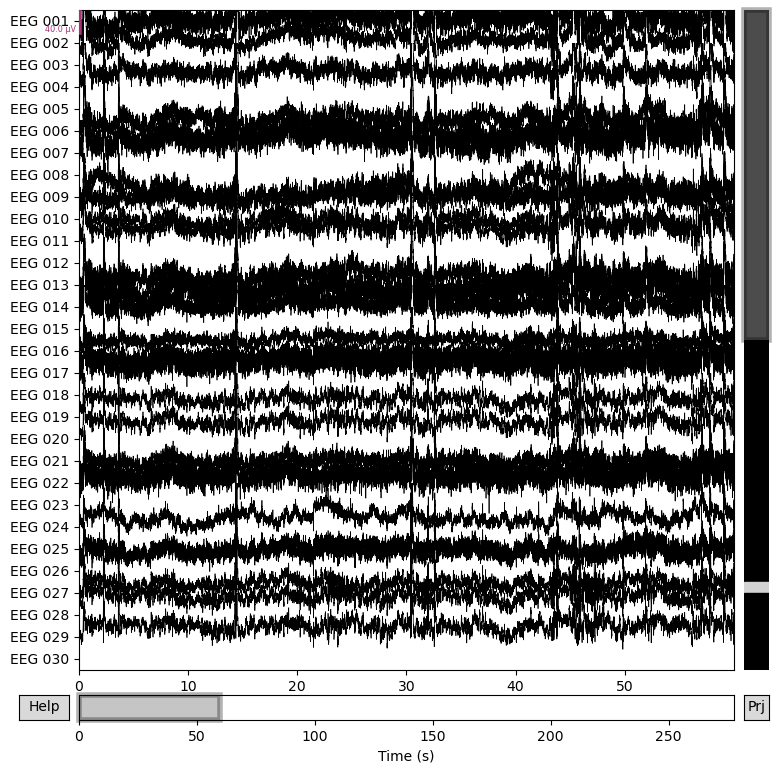

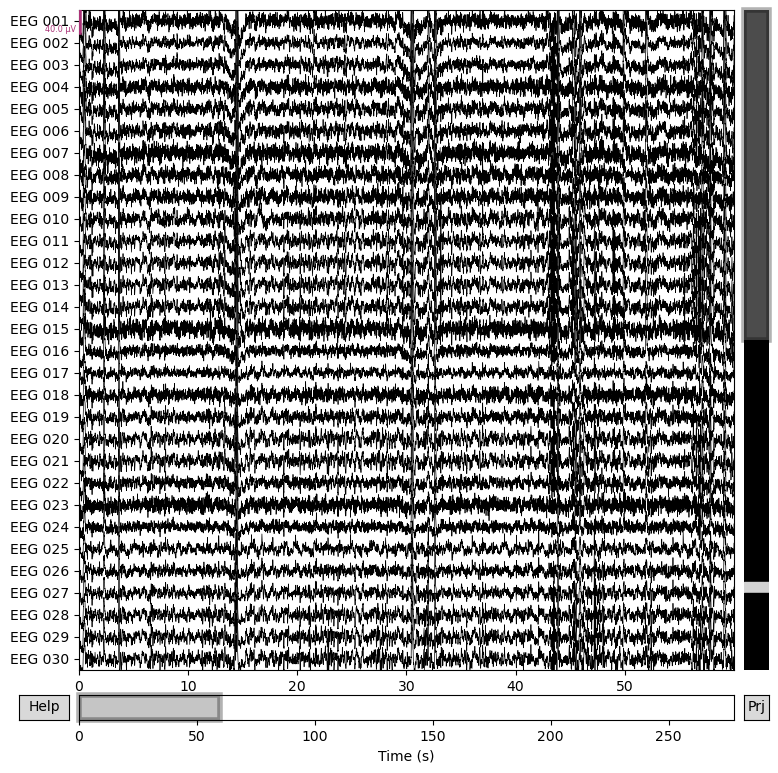

In [7]:
#compare raw and filtered data visually 

#tell mne to use supported plotting backend 
mne.viz.set_browser_backend('matplotlib')

raw.plot(duration=60, proj=False, n_channels=30, remove_dc=False, picks='eeg', title='Raw')
raw_filtered.plot(duration=60, proj=False, n_channels=30, remove_dc=False, picks='eeg', title='Filtered');

## ICA

ICA (Independent Component Analysis) decomposes the recording into statistically independent components, some corresponding to genuine brain activity, others to artifacts like eye movement. Correlating each component against the EOG channel identifies which ones are artefact-related, so they can be excluded while preserving the rest of the signal.

Note:
- n_components=15 keeps this fast and manageable; random_state=42 for reproducibility.
- find_bads_eog correlates each component against the EOG channel and returns indices of components matching blink activity; ica.exclude marks them for removal.
- 1 component (index 0) was flagged as EOG-related and excluded.

This is a different technique from the TDBRAIN authors' own preprocessing, which uses Gratton et al.'s regression-based EOG correction rather than ICA; both use the EOG channel as a reference to remove eye-related artifact, but via different mechanisms (statistical decomposition vs. linear regression subtraction).

In [8]:
ica = mne.preprocessing.ICA(n_components=15, random_state=42, method='fastica')
ica.fit(raw_filtered)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 13.1s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,48 iterations on raw data (166800 samples)
ICA components,15
Available PCA components,364
Channel types,"mag, grad, eeg"
ICA components marked for exclusion,—


In [9]:
#Identify components that correspond to eye blinks and heartbeats
eog_indices, eog_scores = ica.find_bads_eog(raw_filtered)
ica.exclude = eog_indices
print(f"Components flagged as EOG-related: {eog_indices}")

Using EOG channel: EOG 061
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 6007 samples (10.001 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz

In [10]:
#Apply the cleaned result
raw_ica_cleaned = raw_filtered.copy()
ica.apply(raw_ica_cleaned)

Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 364 PCA components


<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>

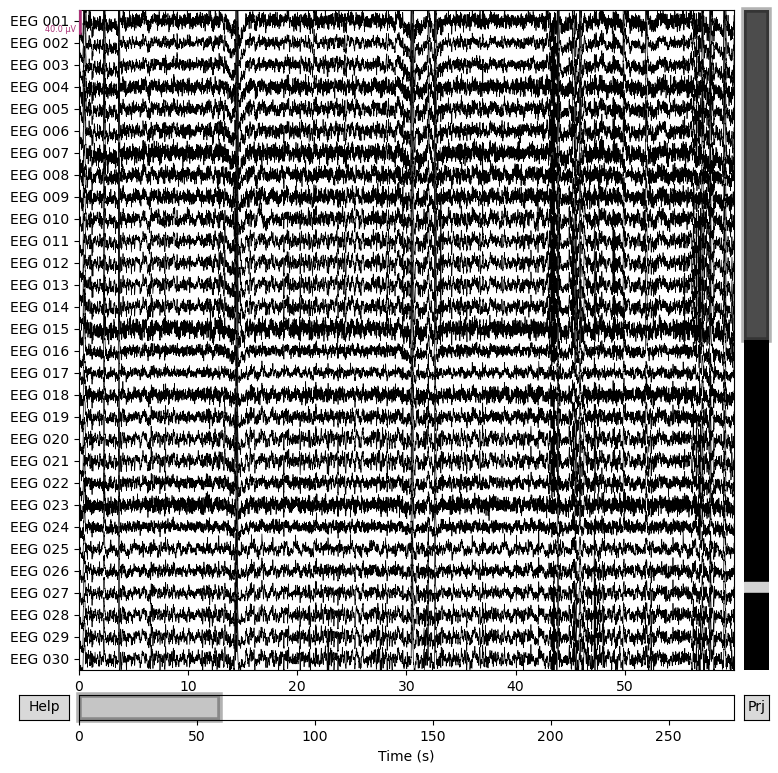

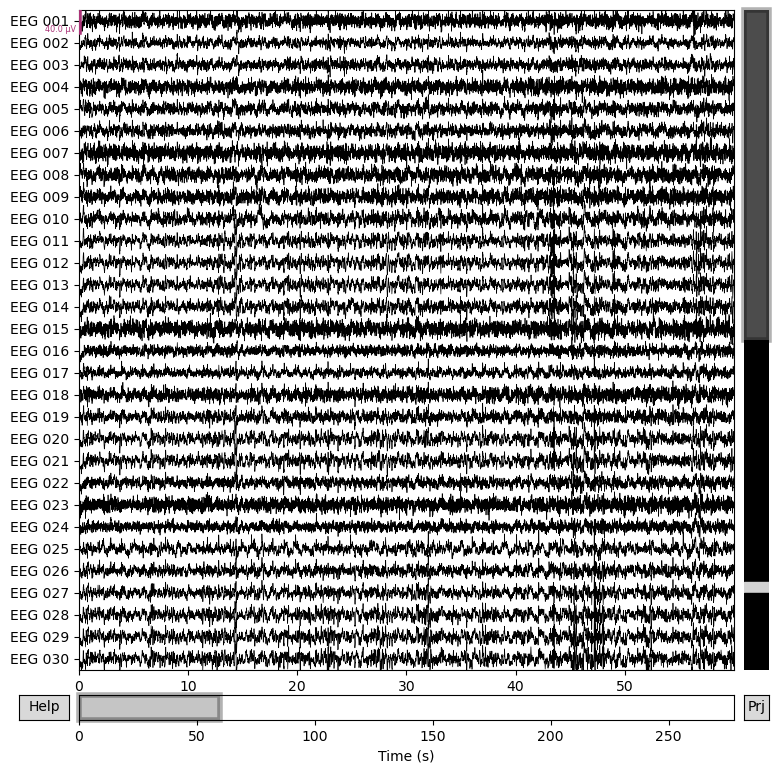

In [11]:
#visual check
raw_filtered.plot(duration=60, n_channels=30, picks='eeg', title='Before ICA')
raw_ica_cleaned.plot(duration=60, n_channels=30, picks='eeg', title='After ICA');

## Epoching

Splitting the continuous, preprocessed recording into fixed-length windows. Since this is resting-state-style data with no task events to align to, fixed-length epoching (rather than event-based epoching) is used, the same approach relevant to TDBRAIN's resting-state structure. Each epoch is a 2-second window, cut consecutively with no overlap.

In [12]:
epochs = mne.make_fixed_length_epochs(raw_ica_cleaned, duration=2.0, preload=True)
print(epochs)

Not setting metadata
138 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Using data from preloaded Raw for 138 events and 1201 original time points ...
0 bad epochs dropped
<Epochs | 138 events (all good), 0 – 1.998 s (baseline off), ~478.7 MiB, data loaded,
 '1': 138>


Created 138 epochs of ~2 seconds each (0–1.998s, accounting for sample-rate rounding), with none rejected. 138 x 2s = ~276s, consistent with the recording's total duration of 277.7s. The small gap reflects a final partial segment too short to form a complete epoch, which is dropped rather than padded.

## Summary

This notebook was used to learn MNE-Python fundamentals before moving to the TDBRAIN dataset. MNE's built-in sample dataset (MEG, not EEG) was downloaded and used to practice core preprocessing steps: loading raw data, inspecting metadata, applying a band-pass filter, and using ICA to identify and remove an artefact component correlated with the EOG channel, before segmenting the cleaned data into fixed-length epochs.

This was tool-learning and conceptual grounding, not a direct comparison against the TDBRAIN authors' own preprocessing method. Their published pipeline uses a different technique (Gratton et al.'s regression-based EOG correction rather than ICA), understanding ICA and filtering here provides the background needed to critically evaluate that published approach, not to replicate it.

For the actual TDBRAIN analysis, preprocessing uses the authors' own peer-reviewed pipeline rather than a custom one built from scratch.